# Clustering analysis

In [1]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from anomaly.utils import get_sdss_spec_img
from anomaly.constants import SDSS_NEBULAR_LINES_RATIOS_NAMES
from astroExplain.spectra import clustering
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data igestion

In [2]:
def load_xai(run_id: str, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_arr = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")
    weights = np.load(f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r")
    return anomalies_arr, specobjids_arr, weights

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "norm_unique_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["norm_unique_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_weights"]
    )

    return data_dict

## Top ranked explanations

In [31]:
def plot_top_ranked_explanations(
    metadata_df,
    spectra,
    norm_weights,
    wave,
    kmeans_model_dir,
    cluster_id,
    donwload_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
):
    lw = 0.75
    n_anomalies_in_cluster = metadata_df.shape[0]
    print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

    for anomaly_rank in range(0, n_anomalies_in_cluster):

        print(f"Explanation for anomaly rank {anomaly_rank + 1}", end="\r")

        if anomaly_rank == n_top_ranked:
            break

        anomaly_idx = n_anomalies_in_cluster - 1 - anomaly_rank
        specobjid = metadata_df.index[anomaly_idx]

        if donwload_images is True:
            os.makedirs(f"{kmeans_model_dir}/cluster_{cluster_id}", exist_ok=True)

            # check if the image already exists
            image_path = (
                f"{kmeans_model_dir}/cluster_{cluster_id}/image_{specobjid}.jpeg"
            )

            if not os.path.exists(image_path):

                ra, dec = metadata_df[["ra", "dec"]].loc[specobjid].values
                get_sdss_spec_img(
                    specobjid,
                    ra,
                    dec,
                    save_to=f"{kmeans_model_dir}/cluster_{cluster_id}",
                )

        spec = spectra[anomaly_idx]

        norm_weights_spec = norm_weights[anomaly_idx]
        if max_norm_weights is True:
            norm_weights_spec /= np.max(norm_weights_spec)

        fig, axs = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(20, 7),
            sharex=True,
            sharey=False,
        )
        # set minor ticks on
        for ax in axs.flatten():
            ax.minorticks_on()
        axs[0].plot(wave, spec, color="black", linewidth=lw)
        # weights
        axs[1].plot(
            wave, norm_weights_spec, color="black",
            label=f"Cluster {cluster_id}", linewidth=lw
        )

        axs[1].set_xlabel(r"$\lambda$ [nm]")
        axs[0].set_ylabel("Normalized flux")
        axs[1].set_ylabel("Explanation weights")
        axs[0].set_title(
            f"Rank: {anomaly_rank + 1:02d} - Cluster: {cluster_id}\n"
            f"Specobjid: {specobjid}"
        )

        axs[1].set_ylim(0, 0.4)
        y_ticks = np.arange(0, 0.41, 0.1)
        axs[1].set_yticks(y_ticks)

        image_name = f"image_{specobjid}.jpeg"
        # Load the image
        img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")

        # Create inset in top-right corner of axs[0]
        width_height_image = 1
        axins = inset_axes(
            axs[0],
            width=width_height_image,
            height=width_height_image,
            bbox_to_anchor=(1.01, 1.02),
            bbox_transform=axs[0].transAxes,
            loc="upper right",
        )

        # Show image in the inset
        axins.imshow(img)
        axins.axis("off")  # Hide axis around the image
        explanation_name = f"rank_{anomaly_rank + 1:02d}_explanation_{specobjid}"
        if max_norm_weights is True:
            explanation_name += "_max_norm"

        save_pdf_dir = f"{kmeans_model_dir}/cluster_{cluster_id}"
        save_jpeg_dir = f"{save_pdf_dir}/explanations_sdss_spec_jpeg"
        # create directories if they don't exist
        os.makedirs(save_pdf_dir, exist_ok=True)
        os.makedirs(save_jpeg_dir, exist_ok=True)
        fig.savefig(f"{save_pdf_dir}/{explanation_name}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_jpeg_dir}/{explanation_name}.jpeg", bbox_inches="tight")
        plt.clf()
        plt.close(fig)

## Explanations

In [5]:
run_ids_343_50k_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607150029_uniform_343_samples_50000_scale_0.9',
    'iforest': 'xai_202607142229_uniform_343_samples_50000_scale_0.9'
}

In [6]:
run_ids_343_dict = {
    'mse': 'xai_202607141207_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250': 'xai_202607141314_uniform_343_samples_50000_scale_0.9',
    'mse_97': 'xai_202607141911_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97': 'xai_202607142055_uniform_343_samples_50000_scale_0.9',
    # ----
    'mse_rel': 'xai_202607132221_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_rel': 'xai_202607132326_uniform_343_samples_50000_scale_0.9',
    'mse_97_rel': 'xai_202607140125_uniform_343_samples_50000_scale_0.9',
    'mse_filter_250_97_rel': 'xai_202607141022_uniform_343_samples_50000_scale_0.9',
    # ---
    'lof': 'xai_202607200003_uniform_343_samples_100000_scale_0.9',
    'iforest': 'xai_202607201307_uniform_343_samples_100000_scale_0.9'
}

# Config

## Directories

In [7]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"
ch_6_dir = f"{thesis_dir}/chapters/06_figures"

## Constants

In [8]:
score_name = "mse_filter_250"
bin_id = "bin_03"
n_segments = 343
n_clusters = 7

kmeans_model_dir = f"{clustering_dir}/{bin_id}/{score_name}"
kmeans_model_name = f"kmeans_{n_clusters}_clusters_{n_segments}_segments"

if not os.path.exists(kmeans_model_dir):
    os.makedirs(kmeans_model_dir)
print(f"Model ID: {kmeans_model_name}")

Model ID: kmeans_7_clusters_343_segments


## Data

In [9]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

## Explanations

In [10]:
n_samples = 100_000

if n_samples == 100_000:
    run_ids_dict = run_ids_343_dict
elif n_samples == 50_000:
    run_ids_dict = run_ids_343_50k_dict

anomalies_dict = {}
specids_dict = {}
weights_dict = {}
run_id = run_ids_dict[score_name]

load_from = f"{explanations_dir}/{bin_id}/{score_name}"
print(f"Loading XAI data from: {load_from}")
(
    anomalies_arr,
    specobjids_arr,
    weights_arr,
) = load_xai(run_id=run_id, load_from=load_from)

weights_dict = weights_prep(
    weights=weights_arr, n_segments=n_segments
)

scores_df = pd.read_csv(
    f"{scores_dir}/{bin_id}/scores_{bin_id}.csv.gz",
    usecols=["specobjid", score_name],
    index_col="specobjid",
).loc[specobjids_arr]

sorted_specobjids_arr = scores_df[score_name].sort_values(
    ascending=False
).index.to_numpy()
scores_df.loc[sorted_specobjids_arr].head(5)

Loading XAI data from: /home/elom/phd/code/explanations/bin_03/mse_filter_250


,mse_filter_250
specobjid,
407596690535639040,51.266237
1413149843194406912,46.806758
378399434137954304,45.940855
1767703038748813312,44.732142
1610143844655982592,41.978454


# K-means model
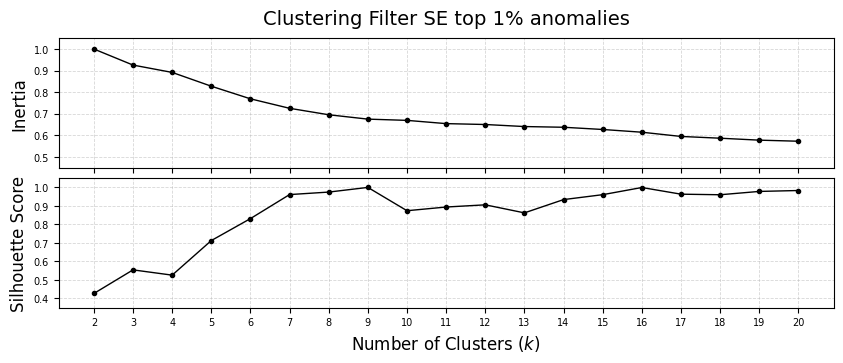

## Train and save

In [11]:
# ```python
start_time = time.perf_counter()

X = weights_dict["norm_unique_weights"]
kmeans_model = KMeans(n_clusters=n_clusters, random_state=0).fit(X)
end_time = time.perf_counter()
print(f"train time: {end_time - start_time:.2f} seconds")

# save model
joblib.dump(kmeans_model, f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
# ```

# ```python
# train time: 0.17 seconds
# [
# '/home/elom/phd/code/clustering/bin_03/mse_filter_250/
# kmeans_7_clusters_343_segments.joblib'
# ]
# ```

train time: 0.17 seconds


['/home/elom/phd/code/clustering/bin_03/mse_filter_250/kmeans_7_clusters_343_segments.joblib']

## Save metadata

In [12]:
# ```python
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")

cluster_meta_df = meta_with_ratios_df.loc[specobjids_arr].copy()
cluster_meta_df["cluster"] = kmeans_model.labels_

cluster_meta_df.to_csv(f"{kmeans_model_dir}/metadata.csv.gz", compression="gzip")
# ```

# Clusters metadata

In [13]:
kmeans_model = joblib.load(f"{kmeans_model_dir}/{kmeans_model_name}.joblib")
cluster_labels = kmeans_model.labels_

# get spectra and weights per cluster
spectra_cluster_dict, weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=weights_dict["norm_weights"],
    print_n_clusters=True,
)

weights_dict["spectra_cluster_dict"] = spectra_cluster_dict
weights_dict["weights_cluster_dict"] = weights_cluster_dict

_, unique_weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=weights_dict["norm_unique_weights"],
    print_n_clusters=False,
)

weights_dict["unique_weights_cluster_dict"] = unique_weights_cluster_dict
centroids = kmeans_model.cluster_centers_
weights_dict["centroids"] = centroids

# 0;376
# 1;194
# 2;217
# 3;594
# 4;80
# 5;286
# 6;72

0;376
1;194
2;217
3;594
4;80
5;286
6;72


In [14]:
cluster_meta_df = pd.read_csv(
    f"{kmeans_model_dir}/metadata.csv.gz", index_col="specobjid"
).loc[sorted_specobjids_arr]

# Line ratios

In [15]:
cluster_meta_df[SDSS_NEBULAR_LINES_RATIOS_NAMES].describe()

,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,sii_to_halpha,sii_density_ratio,o3n2_index
count,1758.000000,1743.000000,1746.000000,1.322000e+03,1.650000e+03,1.656000e+03,1707.000000
mean,85.161960,0.453745,4.053423,2.673445e+00,8.872712e+04,1.503754e+00,0.760342
std,3360.589467,2.072502,36.799671,1.246315e+01,3.604100e+06,4.125504e+00,0.673127
min,0.067116,0.000004,0.002657,4.792498e-08,7.499223e-06,8.169128e-10,-2.534783
25%,3.184590,0.128774,0.747413,6.893489e-01,2.182675e-01,1.262606e+00,0.241183
50%,3.595096,0.275427,1.634219,1.279179e+00,2.796886e-01,1.369167e+00,0.766814
75%,4.164908,0.498437,2.946334,2.588123e+00,3.535170e-01,1.437584e+00,1.229367
max,140901.290334,82.028630,1109.602482,4.273460e+02,1.463992e+08,1.631794e+02,5.525173


In [16]:
# Compute deciles (10th to 90th percentiles) for each column
n_delta = 0.05
deciles = np.arange(n_delta, 1.01, n_delta)
decile_df = cluster_meta_df[SDSS_NEBULAR_LINES_RATIOS_NAMES].quantile(q=deciles).T

decile_df.columns = [f"{int(q * 100)}th" for q in deciles]
decile_df.round(4)

,5th,10th,15th,20th,25th,30th,35th,40th,45th,50th,55th,60th,65th,70th,75th,80th,85th,90th,95th,100th
balmer_decrement,2.0081,2.8601,2.9960,3.0853,3.1846,3.2600,3.3460,3.4073,3.4880,3.5951,3.6854,3.7916,3.8890,4.0131,4.1649,4.3048,4.5128,4.8840,5.7793,1.409013e+05
nii_to_halpha,0.0580,0.0765,0.0925,0.1103,0.1288,0.1565,0.1822,0.2182,0.2457,0.2754,0.3105,0.3425,0.3719,0.4198,0.4984,0.5898,0.6903,0.8611,1.1053,8.202860e+01
oiii_to_hbeta,0.2333,0.3401,0.4595,0.6083,0.7474,0.8867,1.0474,1.2275,1.4114,1.6342,1.8239,2.0289,2.3054,2.6221,2.9463,3.3652,3.9640,4.9073,8.2349,1.109602e+03
oiii_to_oii,0.2568,0.4287,0.5221,0.6017,0.6893,0.8098,0.9145,1.0149,1.1463,1.2792,1.4646,1.6303,1.8666,2.1885,2.5881,3.2181,4.0482,5.3724,7.5612,4.273460e+02
sii_to_halpha,0.1448,0.1671,0.1863,0.2049,0.2183,0.2312,0.2437,0.2578,0.2689,0.2797,0.2908,0.3039,0.3149,0.3323,0.3535,0.3775,0.4114,0.4825,0.6440,1.463992e+08
sii_density_ratio,0.9812,1.0933,1.1657,1.2272,1.2626,1.2926,1.3143,1.3368,1.3544,1.3692,1.3819,1.3968,1.4086,1.4204,1.4376,1.4601,1.4836,1.5240,1.6760,1.631794e+02
o3n2_index,-0.2524,-0.0861,0.0304,0.1338,0.2412,0.3566,0.4794,0.5732,0.6744,0.7668,0.8631,0.9583,1.0319,1.1396,1.2294,1.3597,1.4722,1.6149,1.8034,5.525200e+00


# Median line ratios

In [17]:
median_cluster_ratios_df = pd.DataFrame(
    index=range(0, n_clusters),
    columns=SDSS_NEBULAR_LINES_RATIOS_NAMES,
)
for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id

    median_cluster_ratios_df.loc[cluster_id, "balmer_decrement"] = np.nanmedian(
        cluster_meta_df.loc[mask, "balmer_decrement"]
    )
    median_cluster_ratios_df.loc[cluster_id, "nii_to_halpha"] = np.nanmedian(
        cluster_meta_df.loc[mask, "nii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_hbeta"] = np.nanmedian(
        cluster_meta_df.loc[mask, "oiii_to_hbeta"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_oii"] = np.nanmedian(
        cluster_meta_df.loc[mask, "oiii_to_oii"]
    )
    median_cluster_ratios_df.loc[cluster_id, "o3n2_index"] = np.nanmedian(
        cluster_meta_df.loc[mask, "o3n2_index"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_to_halpha"] = np.nanmedian(
        cluster_meta_df.loc[mask, "sii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_density_ratio"] = np.nanmedian(
        cluster_meta_df.loc[mask, "sii_density_ratio"]
    )
# map col name by replacing the '_' with ' ' for better readability
median_cluster_ratios_df.columns = [
    col.replace("_", " ") for col in median_cluster_ratios_df.columns
]

median_cluster_ratios_df.to_clipboard(excel=True, index=True)
median_cluster_ratios_df

,balmer decrement,nii to halpha,oiii to hbeta,oiii to oii,sii to halpha,sii density ratio,o3n2 index
0,3.382551,0.152592,1.847269,1.384019,0.252377,1.393381,1.100994
1,3.412217,0.099455,3.998161,3.80668,0.202635,1.349828,1.477944
2,3.908915,0.340844,1.420119,1.632396,0.241278,1.319129,0.588288
3,3.435957,0.294969,0.928263,0.773978,0.298171,1.40716,0.44811
4,4.174841,0.586269,2.672293,3.083542,0.316355,1.265788,0.751761
5,3.950562,0.546725,1.033763,1.000537,0.331999,1.326416,0.258465
6,3.961697,0.37167,1.81418,1.657243,0.302422,1.27444,0.767128


In [18]:
percentiles = np.arange(0.45, 0.55, 0.01)
ratios_percentiles_df = cluster_meta_df[
    SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# ].quantile(q=percentiles)

# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,46th,47th,48th,49th,50th,51th,52th,53th,54th,55th
balmer decrement,3.487975,3.506051,3.528186,3.551442,3.570776,3.595096,3.613802,3.625180,3.645039,3.666140,3.685424
nii to halpha,0.245660,0.249400,0.253896,0.261296,0.267933,0.275427,0.283360,0.289788,0.295509,0.303366,0.310543
oiii to hbeta,1.411438,1.452950,1.495171,1.536621,1.588201,1.634219,1.679685,1.709570,1.764755,1.794322,1.823865
oiii to oii,1.146317,1.171467,1.184126,1.224396,1.252324,1.279179,1.305374,1.347160,1.384855,1.412142,1.464562
sii to halpha,0.268890,0.270697,0.272935,0.275420,0.277378,0.279689,0.281651,0.284302,0.286828,0.288601,0.290834
sii density ratio,1.354354,1.357421,1.359972,1.362596,1.366476,1.369167,1.372304,1.374426,1.376302,1.380027,1.381937
o3n2 index,0.674363,0.685889,0.713143,0.734039,0.752545,0.766814,0.789062,0.802273,0.821757,0.849814,0.863104


## Cluster 0 ratios percentiles

In [19]:
cluster_mask = cluster_meta_df["cluster"] == 0
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer decrement,3.292509,3.331587,3.382551,3.408998,3.457419
nii to halpha,0.127688,0.141685,0.152592,0.162644,0.173969
oiii to hbeta,1.654334,1.753277,1.847269,1.987247,2.151773
oiii to oii,1.147912,1.276222,1.384019,1.460719,1.536644
sii to halpha,0.233832,0.242521,0.252377,0.261895,0.270983
sii density ratio,1.369778,1.378264,1.393381,1.398923,1.407617
o3n2 index,0.975782,1.031551,1.100994,1.150703,1.213604


## Cluster 1 ratios percentiles

In [20]:
cluster_mask = cluster_meta_df["cluster"] == 1
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer decrement,3.320670,3.354297,3.412217,3.468995,3.573645
nii to halpha,0.079311,0.086570,0.099455,0.112723,0.131832
oiii to hbeta,3.593675,3.832559,3.998161,4.131004,4.269086
oiii to oii,3.090898,3.375270,3.806680,4.079653,4.849260
sii to halpha,0.177731,0.186406,0.202635,0.220832,0.241333
sii density ratio,1.325890,1.335548,1.349828,1.367576,1.378680
o3n2 index,1.326840,1.426861,1.477944,1.559053,1.651480


## Cluster 2 percentiles

In [21]:
cluster_mask = cluster_meta_df["cluster"] == 2
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer decrement,3.725317,3.846889,3.908915,4.026165,4.094151
nii to halpha,0.258606,0.302812,0.340844,0.353992,0.376114
oiii to hbeta,1.086983,1.262167,1.420119,1.622420,1.803569
oiii to oii,1.366953,1.549561,1.632396,1.730498,1.866318
sii to halpha,0.218977,0.230293,0.241278,0.256833,0.264266
sii density ratio,1.270526,1.295786,1.319129,1.347514,1.361433
o3n2 index,0.460651,0.507199,0.588288,0.685144,0.789594


## Cluster 3 ratios percentiles

In [22]:
cluster_mask = cluster_meta_df["cluster"] == 3
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer decrement,3.232665,3.357591,3.435957,3.580214,3.718017
nii to halpha,0.243308,0.268218,0.294969,0.324040,0.345085
oiii to hbeta,0.684604,0.814040,0.928263,1.088800,1.281018
oiii to oii,0.635078,0.685711,0.773978,0.863612,0.948063
sii to halpha,0.281224,0.291203,0.298171,0.307005,0.316500
sii density ratio,1.380875,1.392524,1.407160,1.416982,1.427799
o3n2 index,0.202900,0.323846,0.448110,0.544998,0.651447


## Cluster 4 ratios percentiles

In [23]:
cluster_mask = cluster_meta_df["cluster"] == 4
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer decrement,4.008857,4.109428,4.174841,4.208495,4.245320
nii to halpha,0.472764,0.533472,0.586269,0.603174,0.630857
oiii to hbeta,1.995485,2.253986,2.672293,2.949050,3.729875
oiii to oii,1.808268,2.138162,3.083542,3.539462,4.172396
sii to halpha,0.304711,0.307938,0.316355,0.336288,0.355559
sii density ratio,1.235829,1.249267,1.265788,1.287406,1.301167
o3n2 index,0.697637,0.733799,0.751761,0.789044,0.820225


## Cluster 5 percentiles

In [24]:
cluster_mask = cluster_meta_df["cluster"] == 5
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer decrement,3.829019,3.880064,3.950562,4.045497,4.176563
nii to halpha,0.443069,0.485583,0.546725,0.621788,0.681553
oiii to hbeta,0.777677,0.905915,1.033763,1.274714,1.447879
oiii to oii,0.812997,0.883580,1.000537,1.145716,1.260138
sii to halpha,0.304896,0.314960,0.331999,0.362262,0.386700
sii density ratio,1.263499,1.291864,1.326416,1.347179,1.379830
o3n2 index,0.101835,0.158821,0.258465,0.309420,0.347038


## Cluster 6 percentiles

In [25]:
cluster_mask = cluster_meta_df["cluster"] == 6
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = cluster_meta_df.loc[
    cluster_mask, SDSS_NEBULAR_LINES_RATIOS_NAMES
].quantile(q=percentiles).T
# map index name by replacing the '_' with ' ' for better readability
ratios_percentiles_df.index = [
    idx.replace("_", " ") for idx in ratios_percentiles_df.index
]
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer decrement,3.849194,3.909073,3.961697,4.040449,4.072461
nii to halpha,0.317650,0.344185,0.371670,0.420270,0.482425
oiii to hbeta,1.419686,1.695123,1.814180,2.235682,2.755392
oiii to oii,1.366513,1.480041,1.657243,2.580025,3.484046
sii to halpha,0.285499,0.289863,0.302422,0.317567,0.328338
sii density ratio,1.259288,1.265226,1.274440,1.284141,1.299889
o3n2 index,0.699212,0.743856,0.767128,0.778986,0.801910


# Redshift Analysis

In [26]:
z_dict = {"cluster": [], "z_min": [], "z_max": [], "z_mean": [], "z_median": []}

for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id
    z = cluster_meta_df["z"].loc[mask].values

    z_dict["cluster"].append(cluster_id)
    z_dict["z_min"].append(np.min(z))
    z_dict["z_max"].append(np.max(z))
    z_dict["z_mean"].append(np.mean(z))
    z_dict["z_median"].append(np.median(z))
z_df = pd.DataFrame(z_dict)
z_df

,cluster,z_min,z_max,z_mean,z_median
0,0,0.011578,0.237981,0.050237,0.032617
1,1,0.010132,0.203136,0.050397,0.031121
2,2,0.010093,0.282081,0.083597,0.071541
3,3,0.010147,0.294866,0.072883,0.054034
4,4,0.115653,0.121787,0.118576,0.118439
5,5,0.016985,0.243756,0.099232,0.089569
6,6,0.074165,0.110988,0.107917,0.108249


In [27]:
low_wave, upper_wave = 5_565, 5_590
z_df["lower_wave_min"] = low_wave / (1 + z_df["z_min"])
z_df["upper_wave_min"] = upper_wave / (1 + z_df["z_min"])
z_df["lower_wave_max"] = low_wave / (1 + z_df["z_max"])
z_df["upper_wave_max"] = upper_wave / (1 + z_df["z_max"])
z_df["lower_wave_mean"] = low_wave / (1 + z_df["z_mean"])
z_df["upper_wave_mean"] = upper_wave / (1 + z_df["z_mean"])
z_df["lower_wave_median"] = low_wave / (1 + z_df["z_median"])
z_df["upper_wave_median"] = upper_wave / (1 + z_df["z_median"])
z_df

,cluster,z_min,z_max,z_mean,z_median,lower_wave_min,upper_wave_min,lower_wave_max,upper_wave_max,lower_wave_mean,upper_wave_mean,lower_wave_median,upper_wave_median
0,0,0.011578,0.237981,0.050237,0.032617,5501.307240,5526.021109,4495.221374,4515.415540,5298.805328,5322.609484,5389.218904,5413.429231
1,1,0.010132,0.203136,0.050397,0.031121,5509.182778,5533.932027,4625.412256,4646.191287,5297.998940,5321.799474,5397.036192,5421.281638
2,2,0.010093,0.282081,0.083597,0.071541,5509.396417,5534.146625,4340.597692,4360.097233,5135.675105,5158.746422,5193.456730,5216.787623
3,3,0.010147,0.294866,0.072883,0.054034,5509.099062,5533.847934,4297.740346,4317.047356,5186.960774,5210.262485,5279.716361,5303.434763
4,4,0.115653,0.121787,0.118576,0.118439,4988.110102,5010.518504,4960.836580,4983.122458,4975.073630,4997.423466,4975.683081,4998.035656
5,5,0.016985,0.243756,0.099232,0.089569,5472.056949,5496.639415,4474.352073,4494.452487,5062.626457,5085.369612,5107.523512,5130.468361
6,6,0.074165,0.110988,0.107917,0.108249,5180.766919,5204.040805,5009.054102,5031.556591,5022.941604,5045.506481,5021.436753,5043.994869


# Centroids

In [28]:
lw = 0.75
for label, centroid in enumerate(weights_dict["centroids"]):

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    centroid = clustering.expand_weights_per_segments(
        centroid.reshape(1, -1),
        wave_nm.size,
        n_segments,
    )

    centroid = centroid.reshape(-1)
    avg_spectrum = weights_dict["spectra_cluster_dict"][label].mean(axis=0)

    axs[0].plot(
        wave_nm, avg_spectrum, color="black", label="Average spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, centroid, color="black", label="Average explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    axs[1].set_ylim(0, 1.1)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label}",
        fontsize=12,
    )

    plot_name = f"avg_spec_centroid_{label}"

    save_to = f"{kmeans_model_dir}/avg_spec_centroids"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

# Avg Explanation

In [29]:
lw = 0.75
for label_cluster, weights in weights_dict['weights_cluster_dict'].items():

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(20, 7),
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()
    spec = weights_dict["spectra_cluster_dict"][label_cluster]

    avg_spectrum = spec.mean(axis=0)
    avg_weights = weights.mean(axis=0)

    axs[0].plot(
        wave_nm, avg_spectrum, color="black", label="Average spectrum", linewidth=lw
    )
    axs[0].legend()
    # weights
    axs[1].plot(
        wave_nm, avg_weights, color="black", label="Average explanation", linewidth=lw
    )
    axs[1].legend()
    # set limits
    axs[1].set_ylim(0, 0.31)
    y_ticks = np.arange(0, 0.31, 0.1)
    axs[1].set_yticks(y_ticks)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label_cluster}",
        fontsize=12,
    )

    plot_name = f"avg_spec_xai_{label_cluster}"

    save_to = f"{kmeans_model_dir}/avg_spec_xai"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

# Top ranked anomalies per cluster

In [40]:
cluster_id = 0

mask = cluster_meta_df["cluster"] == cluster_id

metadata_df = cluster_meta_df.loc[mask].copy()

spectra = anomalies_arr[mask]
norm_weights = weights_dict["norm_weights"][mask]

plot_top_ranked_explanations(
    cluster_id=cluster_id,
    metadata_df=metadata_df,
    spectra=spectra,
    norm_weights=norm_weights,
    wave=wave_nm,
    kmeans_model_dir=kmeans_model_dir,
    donwload_images=True,
    n_top_ranked=50,
    max_norm_weights=False,
)

Number of anomalies in cluster 0: 376
